In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


In [2]:
df=pd.read_csv('titanic_data_updated (2).csv')
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Starter, Train Test and Handling Missing Values

In [3]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [4]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [5]:
x=df.drop(['Survived'],axis=1) # column ta bad
x


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [6]:
y = df['Survived']
y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

Train Test Split Code





In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [8]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


In [9]:
display(y_train)

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [10]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


In [11]:
y_test

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

 Numerical Missing Value Imputation with Pandas

In [12]:
df.isnull().sum()


Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [13]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [14]:
x_test.isnull().sum()

Pclass        0
Sex           0
Age          37
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [15]:
# 80% train er age ter mean us korbo null e

age_mean=x_train['Age'].mean()

age_mean

np.float64(29.498846153846156)

In [16]:
age_mean=x_train['Age'].mean()
x_train['new_age_mean']=x_train['Age'].fillna(age_mean)
x_test['new_age_mean']=x_test['Age'].fillna(age_mean)

# dekho nun value gola 29.498846153846156 dia fillup hoi gese


In [17]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,new_age_mean
331,first,male,45.5,0,0,28.5000,C124,S,45.500000
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000
...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000


In [18]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,new_age_mean
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000
720,second,female,6.0,0,1,33.0000,NaN,S,6.000000
39,third,female,14.0,1,0,11.2417,NaN,C,14.000000
...,...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S,17.000000
773,third,male,NaN,0,0,7.2250,NaN,C,29.498846
25,third,female,38.0,1,5,31.3875,NaN,S,38.000000
84,second,female,17.0,0,0,10.5000,NaN,S,17.000000


In [19]:
#median impute

age_median = x_train['Age'].median()

print(age_median)
print()

x_train['new_age_median'] = x_train['Age'].fillna(age_median)

x_test['new_age_median'] = x_test['Age'].fillna(age_median)

x_train

28.0



,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,new_age_mean,new_age_median
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


In [20]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,new_age_mean,new_age_median
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846,28.0
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000,31.0
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000,20.0
720,second,female,6.0,0,1,33.0000,NaN,S,6.000000,6.0
39,third,female,14.0,1,0,11.2417,NaN,C,14.000000,14.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S,17.000000,17.0
773,third,male,NaN,0,0,7.2250,NaN,C,29.498846,28.0
25,third,female,38.0,1,5,31.3875,NaN,S,38.000000,38.0
84,second,female,17.0,0,0,10.5000,NaN,S,17.000000,17.0


<Axes: xlabel='new_age_median', ylabel='Density'>

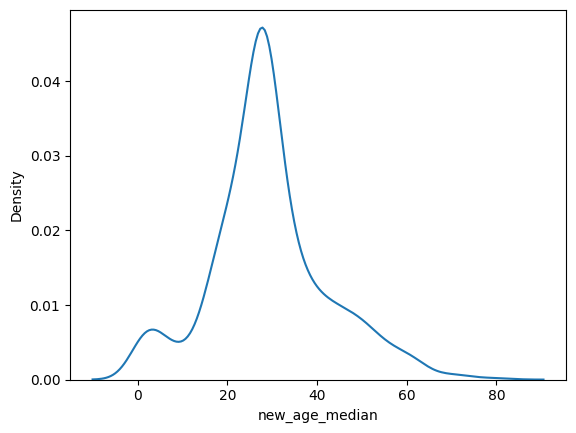

In [21]:
# doiketre graph graph ta praiee akoi noicer doit agraph
# akta mena arek median er x_train er graph

sns.kdeplot(data=x_train,x='new_age_median')


<Axes: xlabel='new_age_mean', ylabel='Density'>

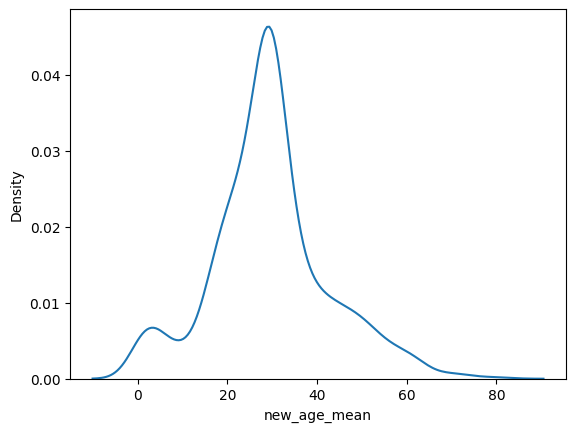

In [22]:
sns.kdeplot(data=x_train,x='new_age_mean')
#

<Axes: xlabel='new_age_mean', ylabel='Density'>

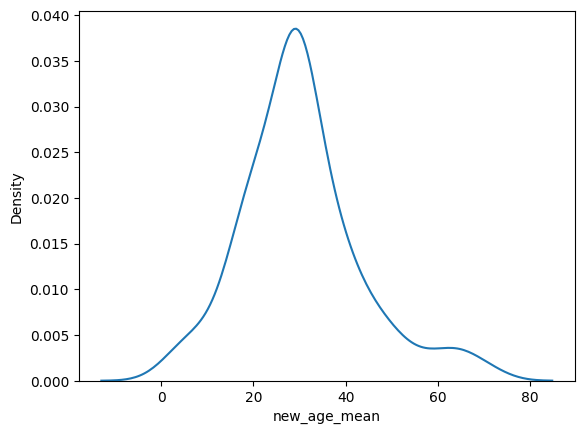

In [23]:
sns.kdeplot(data=x_test,x='new_age_mean')

<Axes: xlabel='new_age_median', ylabel='Density'>

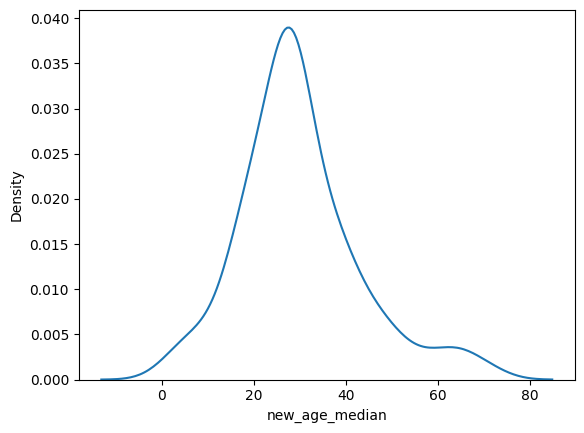

In [24]:
sns.kdeplot(data=x_test,x='new_age_median')

Numerical Missing Values Imputation using Simple Imputer

In [25]:
from sklearn.impute import SimpleImputer

age_imputer=SimpleImputer(missing_values=np.nan,strategy='mean') # mean value dia fill up korba
age_imputer.fit(x_train[['Age']])                                # 2d format e
x_train['Age']=age_imputer.transform(x_train[['Age']])           # train er part ta beshi man ace tai or mean tai test eo bosaici


x_train['Age']

331    45.500000
733    23.000000
382    32.000000
704    26.000000
813     6.000000
         ...    
106    21.000000
270    29.498846
860    41.000000
435    14.000000
102    21.000000
Name: Age, Length: 712, dtype: float64

In [26]:
x_train.isnull().sum()

x_train.drop(['new_age_mean','new_age_median'],axis=1,inplace=True)

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,NaN,S
382,third,male,32.000000,0,0,7.9250,NaN,S
704,third,male,26.000000,1,0,7.8542,NaN,S
813,third,female,6.000000,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S
270,first,male,29.498846,0,0,31.0000,NaN,S
860,third,male,41.000000,2,0,14.1083,NaN,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [27]:
x_test['Age']=age_imputer.transform(x_test[['Age']])
x_test['Age']


709    29.498846
439    31.000000
840    20.000000
720     6.000000
39     14.000000
         ...    
433    17.000000
773    29.498846
25     38.000000
84     17.000000
10      4.000000
Name: Age, Length: 179, dtype: float64

In [28]:
x_test.isnull().sum()

Pclass              0
Sex                 0
Age                 0
SibSp               0
Parch               0
Fare                0
Cabin             134
Embarked            0
new_age_mean        0
new_age_median      0
dtype: int64

In [29]:
x_test.drop(['new_age_mean','new_age_median'],axis=1,inplace=True)

x_test


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


In [30]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [31]:
embarked_imputer=SimpleImputer(missing_values=np.nan,strategy='most_frequent') # jeta beshi seta nei most frequent
embarked_imputer.fit(x_train[['Embarked']])

x_train['Embarked']=embarked_imputer.transform(x_train[['Embarked']]).ravel()

 # fit embarked er sorbocco value ta nia null e bopsai dei

x_test['Embarked']=embarked_imputer.transform(x_test[['Embarked']]).ravel()


In [32]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,NaN,S
382,third,male,32.000000,0,0,7.9250,NaN,S
704,third,male,26.000000,1,0,7.8542,NaN,S
813,third,female,6.000000,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S
270,first,male,29.498846,0,0,31.0000,NaN,S
860,third,male,41.000000,2,0,14.1083,NaN,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [33]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
dtype: int64

In [34]:
x_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [35]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
dtype: int64

Categorical Value Imputation with Missing string and Indicator

<Axes: xlabel='Cabin', ylabel='count'>

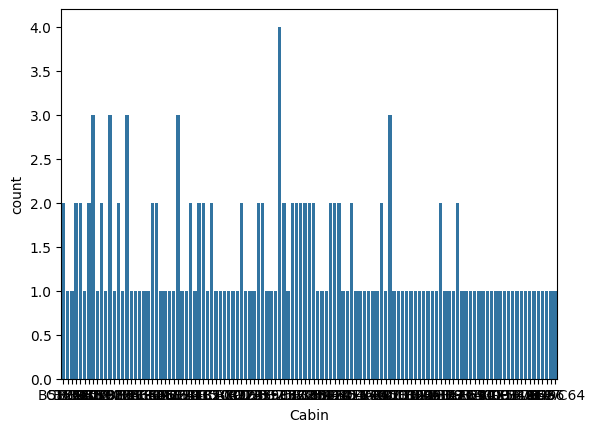

In [36]:
sns.countplot(data = x_train , x=x_train['Cabin'])

In [37]:
cabin_imputer = SimpleImputer(missing_values=np.nan , strategy='constant',fill_value='Missing',add_indicator=True)

cabin_imputer.fit(x_train[['Cabin']])

# transform both train and test data

x_train[['Cabin','cabin_missing_indicator']]= cabin_imputer.transform(x_train[['Cabin']])
x_test[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(x_test[['Cabin']])

In [38]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False


In [39]:
x_train.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

In [40]:

x_test.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

## outlier detection

## Z-Score

In [41]:
mean_age=x_train['Age'].mean()
std_age=x_train['Age'].std()
x_train['z_score_age']=(x_train['Age']-mean_age)/std_age
x_train


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,z_score_age
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00


In [42]:
outliers=x_train[abs(x_train['z_score_age'])>3]
print(len(outliers))
display(outliers)

# keyal kore dekho 	z_score_age er value 3 er beshi jara ache tader ke outlier hisabe dekhacce

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,z_score_age
116,third,male,70.5,0,0,7.750,Missing,Q,True,3.155317
745,first,male,70.0,1,1,71.000,B22,S,False,3.116839
630,first,male,80.0,0,0,30.000,A23,S,False,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,True,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,True,3.116839


In [43]:
mean_of_fare=x_train['Fare'].mean()
std_of_fare=x_train['Fare'].std()
x_train['z_score_fare']=(x_train['Fare']-mean_of_fare)/std_of_fare

print(std_of_fare)
print(mean_of_fare)
x_train

51.96952935247804
32.5862761235955


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,z_score_age,z_score_fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [44]:
outliers_fare = x_train[abs(x_train['z_score_fare']) > 3]

print(len(outliers_fare))

display(outliers_fare)

# Keyal kore dekho 	z_score_fare er value 3 er beshi jara ache tader ke outlier hisabe dekhacce



17


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,z_score_age,z_score_fare
118,first,male,24.000000,0,1,247.5208,B58 B60,C,False,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,False,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,False,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,False,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,True,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,False,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,False,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,False,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,False,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,True,2.734055e-16,3.751020


## Outliers with IQR

In [45]:
age_q1=x_train['Age'].quantile(0.25)
age_q3=x_train['Age'].quantile(0.75)
age_IQR = age_q3 - age_q1

age_minimum=age_q1 - 1.5*age_IQR
age_maximum=age_q3 + 1.5*age_IQR
print(age_q1)
print(age_q3)
print(age_IQR)
print(age_minimum)
print(age_maximum)

22.0
35.0
13.0
2.5
54.5


In [46]:
age_outliers=x_train[(x_train['Age']<age_minimum) | (x_train['Age']>age_maximum)]
print(len(age_outliers))
display(age_outliers)

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,z_score_age,z_score_fare
326,third,male,61.00,0,0,6.2375,Missing,S,True,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,True,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,True,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,False,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,False,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,True,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,False,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,True,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,True,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,True,-2.193180,-0.324124


In [47]:
fare_q1=x_train['Fare'].quantile(0.25)
fare_q3=x_train['Fare'].quantile(0.75)
fare_IQR = fare_q3 - fare_q1
fare_minimum=max(0,fare_q1-1.5*fare_IQR)
fare_maximum=fare_q3+1.5*fare_IQR

print(fare_minimum , fare_maximum)

0 64.3625


In [48]:
fare_outlier_IQR = x_train[(x_train['Fare']<fare_minimum) | (x_train['Fare']>fare_maximum)]

print(len(fare_outlier_IQR))
display(fare_outlier_IQR)

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,z_score_age,z_score_fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,False,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,False,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,False,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,False,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,False,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,False,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,True,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,False,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,False,-1.192742,1.682019


In [49]:
# z score outlier detection is better for age outliers

# zscore jader 3 er choto ba shoman shudhu matro tader kei amra train e rakhtesi
x_train = x_train[abs(x_train['z_score_age']) <=3]

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,z_score_age,z_score_fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [50]:
minimum_zscore_fare = x_train[abs(x_train['z_score_fare']) <=3]['Fare'].max()

print((minimum_zscore_fare))

164.8667


In [51]:
# iqr is better for fare

x_train['Fare']= x_train['Fare'].clip(fare_minimum , fare_maximum)

x_train['Fare'].max()

C:\Users\Sayed\AppData\Local\Temp\ipykernel_17804\1972275673.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['Fare']= x_train['Fare'].clip(fare_minimum , fare_maximum)


64.3625

In [52]:
x_train.drop(['z_score_age','z_score_fare'],axis=1 , inplace=True)

x_train

C:\Users\Sayed\AppData\Local\Temp\ipykernel_17804\1345590643.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train.drop(['z_score_age','z_score_fare'],axis=1 , inplace=True)


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False


<Axes: xlabel='Pclass', ylabel='Count'>

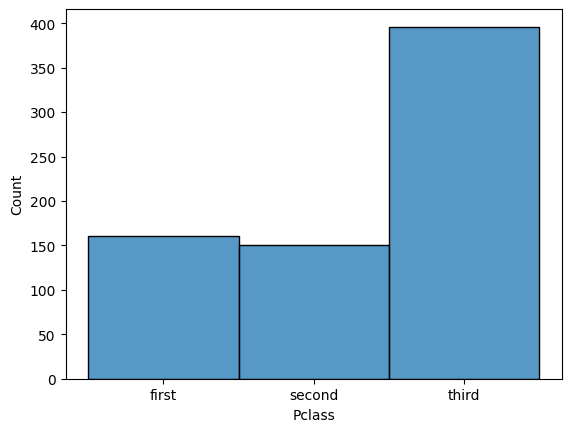

In [53]:
sns.histplot(data=x_train,x='Pclass')

Encoding part

In [54]:
## Ordinal Catagory

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
pclass_encoder=OrdinalEncoder(categories=[['third','second','first']])
pclass_encoder.fit(x_train[['Pclass']])
x_train['Pclass']=pclass_encoder.transform(x_train[['Pclass']])
x_test['Pclass']=pclass_encoder.transform(x_test[['Pclass']])



C:\Users\Sayed\AppData\Local\Temp\ipykernel_17804\893132089.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['Pclass']=pclass_encoder.transform(x_train[['Pclass']])


In [55]:
x_train

#  pclass ta dekho
# 3 ta part k easily 0,1,2 te rakte pari model bojte pare easily
# aijonno ordinal catagory bhalo

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,2.0,male,45.500000,0,0,28.5000,C124,S,False
733,1.0,male,23.000000,0,0,13.0000,Missing,S,True
382,0.0,male,32.000000,0,0,7.9250,Missing,S,True
704,0.0,male,26.000000,1,0,7.8542,Missing,S,True
813,0.0,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,0.0,female,21.000000,0,0,7.6500,Missing,S,True
270,2.0,male,29.498846,0,0,31.0000,Missing,S,True
860,0.0,male,41.000000,2,0,14.1083,Missing,S,True
435,2.0,female,14.000000,1,2,64.3625,B96 B98,S,False


In [56]:
# nominal encodding
embarked_Ohe=OneHotEncoder(sparse_output=False).set_output(transform='pandas')
embarked_Ohe.fit(x_train[['Embarked']])

# x_train er jonno
encoded_df=embarked_Ohe.transform(x_train[['Embarked']])
x_train=pd.concat([x_train,encoded_df],axis=1)

# x_test er jonno
encoded_df = embarked_Ohe.transform(x_test[['Embarked']])
x_test = pd.concat([x_test,encoded_df],axis =1)



In [57]:
x_train.sample(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S
160,0.0,male,44.000000,0,1,16.1000,Missing,S,True,0.0,0.0,1.0
419,0.0,female,10.000000,0,2,24.1500,Missing,S,True,0.0,0.0,1.0
555,2.0,male,62.000000,0,0,26.5500,Missing,S,True,0.0,0.0,1.0
473,1.0,female,23.000000,0,0,13.7917,D,C,False,1.0,0.0,0.0
738,0.0,male,29.498846,0,0,7.8958,Missing,S,True,0.0,0.0,1.0
102,2.0,male,21.000000,0,1,64.3625,D26,S,False,0.0,0.0,1.0
127,0.0,male,24.000000,0,0,7.1417,Missing,S,True,0.0,0.0,1.0
24,0.0,female,8.000000,3,1,21.0750,Missing,S,True,0.0,0.0,1.0
114,0.0,female,17.000000,0,0,14.4583,Missing,C,True,1.0,0.0,0.0
324,0.0,male,29.498846,8,2,64.3625,Missing,S,True,0.0,0.0,1.0


In [58]:
x_train.drop(['Pclass','Sex','Embarked'],axis=1 , inplace= True)
x_test.drop(['Pclass','Sex','Embarked'],axis=1 , inplace= True)

In [59]:
x_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S
331,45.500000,0,0,28.5000,C124,False,0.0,0.0,1.0
733,23.000000,0,0,13.0000,Missing,True,0.0,0.0,1.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0
813,6.000000,4,2,31.2750,Missing,True,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,0.0,1.0
270,29.498846,0,0,31.0000,Missing,True,0.0,0.0,1.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0
435,14.000000,1,2,64.3625,B96 B98,False,0.0,0.0,1.0


In [60]:
x_train['Cabin'].value_counts()

Cabin
Missing        550
C23 C25 C27      4
C22 C26          3
B96 B98          3
F2               3
              ... 
A14              1
D49              1
C87              1
D56              1
C62 C64          1
Name: count, Length: 117, dtype: int64

In [61]:
# one hot encoding
x_train['Cabin'].dtype


dtype('O')

In [62]:
x_train['Cabin_Deck']=x_train['Cabin'].astype(str).str[0]
# astype ta
#সব value কে string বানাচ্ছে।
#কারণ কিছু value NaN থাকতে পারে।
#String না বানালে .str কাজ নাও করতে পারে।
x_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck
331,45.500000,0,0,28.5000,C124,False,0.0,0.0,1.0,C
733,23.000000,0,0,13.0000,Missing,True,0.0,0.0,1.0,M
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,M
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,M
813,6.000000,4,2,31.2750,Missing,True,0.0,0.0,1.0,M
...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,0.0,1.0,M
270,29.498846,0,0,31.0000,Missing,True,0.0,0.0,1.0,M
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,M
435,14.000000,1,2,64.3625,B96 B98,False,0.0,0.0,1.0,B


In [63]:
x_test['Cabin_Deck'] = x_test['Cabin'].astype(str).str[0]
x_test

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck
709,29.498846,1,1,15.2458,Missing,True,1.0,0.0,0.0,M
439,31.000000,0,0,10.5000,Missing,True,0.0,0.0,1.0,M
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,M
720,6.000000,0,1,33.0000,Missing,True,0.0,0.0,1.0,M
39,14.000000,1,0,11.2417,Missing,True,1.0,0.0,0.0,M
...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,1.0,M
773,29.498846,0,0,7.2250,Missing,True,1.0,0.0,0.0,M
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,1.0,M
84,17.000000,0,0,10.5000,Missing,True,0.0,0.0,1.0,M


In [64]:
deck_ohe = OneHotEncoder(sparse_output=False,drop='first').set_output(transform='pandas')

deck_ohe.fit(x_train[['Cabin_Deck']])


encoded_df = deck_ohe.transform(x_train[['Cabin_Deck']])
x_train = pd.concat([x_train,encoded_df],axis =1)


display(encoded_df)
x_train

,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
106,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,C124,False,0.0,0.0,1.0,C,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,14.000000,1,2,64.3625,B96 B98,False,0.0,0.0,1.0,B,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
encoded_df = deck_ohe.transform(x_test[['Cabin_Deck']])
x_test = pd.concat([x_test,encoded_df],axis =1)
x_test



,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
709,29.498846,1,1,15.2458,Missing,True,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
439,31.000000,0,0,10.5000,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
720,6.000000,0,1,33.0000,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39,14.000000,1,0,11.2417,Missing,True,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
773,29.498846,0,0,7.2250,Missing,True,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
84,17.000000,0,0,10.5000,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [66]:
x_train.drop('Cabin_Deck',axis=1, inplace=True) # first word ola cabin deck ta lagtese na
x_test.drop('Cabin_Deck',axis=1, inplace=True)

In [67]:
x_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,C124,False,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,14.000000,1,2,64.3625,B96 B98,False,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [68]:
# y part ta holo target columns
# akne korbo label encodding
y_train

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [69]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(y_train)

y_train=le.transform(y_train)
y_test=le.transform(y_test)

In [70]:
y_test

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1])

In [71]:
y_train

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,

In [72]:
y_train=pd.DataFrame(y_train,columns=['Survived'])
y_train

,Survived
0,0
1,0
2,0
3,0
4,0
...,...
707,1
708,0
709,0
710,1


In [ ]:
y_test=pd.DataFrame(y_test,columns=['Survived'])


,Survived
0,1
1,0
2,0
3,1
4,1
...,...
174,0
175,0
176,1
177,1


In [75]:
y_test

,Survived
0,1
1,0
2,0
3,1
4,1
...,...
174,0
175,0
176,1
177,1


<Axes: xlabel='Age', ylabel='Density'>

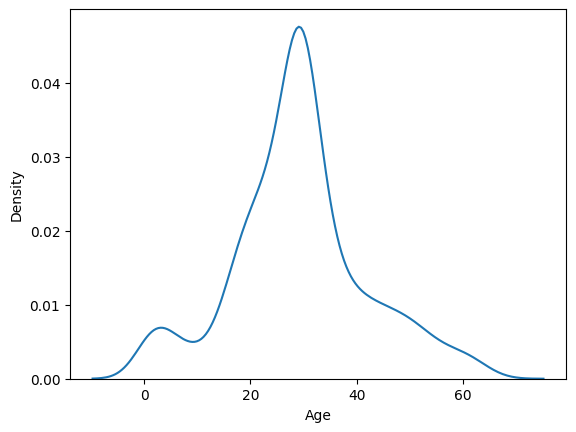

In [78]:
sns.kdeplot(data = x_train , x ='Age')

In [81]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(x_train[['Age']])
x_train['Age']=ss.transform(x_train[['Age']])
x_test['Age']=ss.transform(x_test[['Age']])

In [82]:
x_train.sample(5)

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
214,0.024552,1,0,7.7500,Missing,True,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
138,-1.055229,0,0,9.2167,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
217,1.024527,1,0,27.0000,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
562,-0.095341,0,0,13.5000,Missing,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
681,-0.175332,0,0,64.3625,D49,False,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [84]:
round(x_train['Age'].mean(),5)

np.float64(0.0)

In [85]:
round(x_train['Age'].std(),5)

1.00071

In [ ]:
## Z-Score outlier detect করতে use হয়, আর Standard Scaling ML model এর feature scaling এর জন্য use হয়।

# Standard Scaling age আর salary এর মতো different range এর feature গুলোকে same scale এ এনে তাদের মধ্যে balanced relation তৈরি করে, যাতে কোনো feature অতিরিক্ত গুরুত্ব না পায়।

# Standard Scaling হলো data কে এমনভাবে scale করা যাতে feature এর mean = 0 আর standard deviation = 1 হয়, ফলে সব feature একই scale এ আসে এবং ML model ভালো perform করে।

<Axes: xlabel='Age', ylabel='Density'>

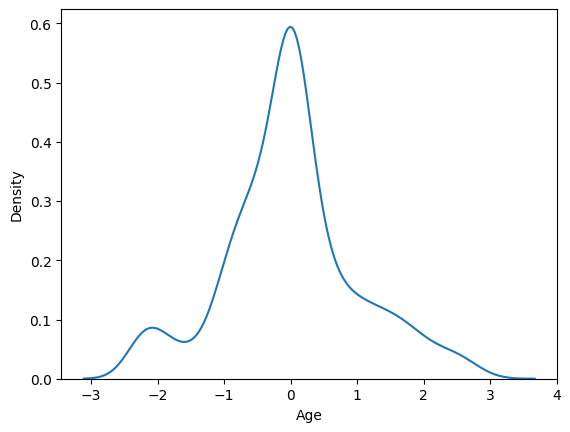

In [86]:
sns.kdeplot(data = x_train , x ='Age')

<Axes: xlabel='Fare', ylabel='Density'>

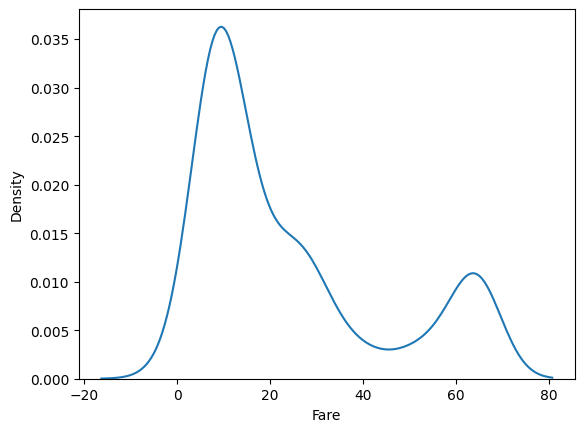

In [87]:
sns.kdeplot(data = x_train , x='Fare')

In [ ]:
from sklearn.preprocessing import MinMaxScaler
 

mms = MinMaxScaler()

mms.fit(x_train[['Fare']])

x_train['Fare'] = mms.transform(x_train[['Fare']]).ravel()
x_test['Fare'] = mms.transform(x_test[['Fare']]).ravel()

In [89]:
x_train['Fare'].describe()

count    707.000000
mean       0.368633
std        0.313162
min        0.000000
25%        0.123131
50%        0.224575
75%        0.473878
max        1.000000
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Density'>

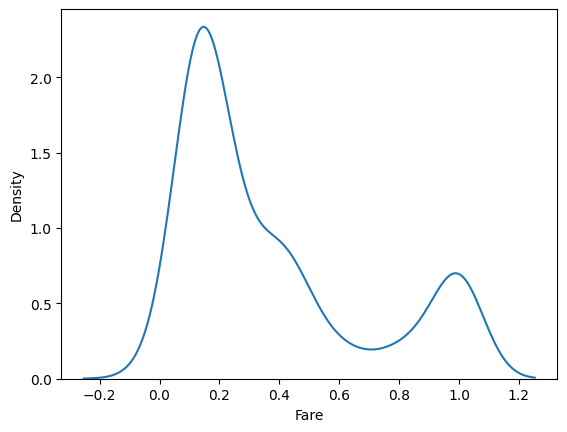

In [ ]:
sns.kdeplot(data = x_train , x='Fare')